# Assignment 3 ()
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 3.1: Bayesian Linear Regression (25 points)
Implement Bayesian linear regression using PyMC:

• Use a polynomial regression problem with noisy data (use synthetic data
or Advertising Dataset from Kaggle).

• Set appropriate priors for coefficients and noise.

• Sample from the posterior using MCMC.

• Visualize posterior distributions and credible intervals.

• Compare with standard maximum likelihood estimation.

In [8]:
SEED = 123

## Problem 3.2: Gaussian Process Regression (25 points)
Apply Gaussian Processes to function approximation:

• Use GPyTorch or scikit-learn.

• Test on synthetic 1D and 2D functions.

• Use Mauna Loa CO2 dataset or temperature time series from your hometown

• Experiment with different kernels (RBF, Matern, Periodic).

• Visualize mean predictions and uncertainty bounds.

• Discuss computational complexity for large datasets.

## Problem 3.3: ARIMA Modeling (25 points)
Forecast stock prices using ARIMA:

• Download daily prices for any stock (2+ years of data).

• Check for stationarity using ADF test.

• Use ACF/PACF plots to determine ARIMA order.

• Fit ARIMA model and validate using last 20% of data.

• Generate 30-day forecast with confidence intervals.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### Load the data

[*********************100%***********************]  1 of 1 completed


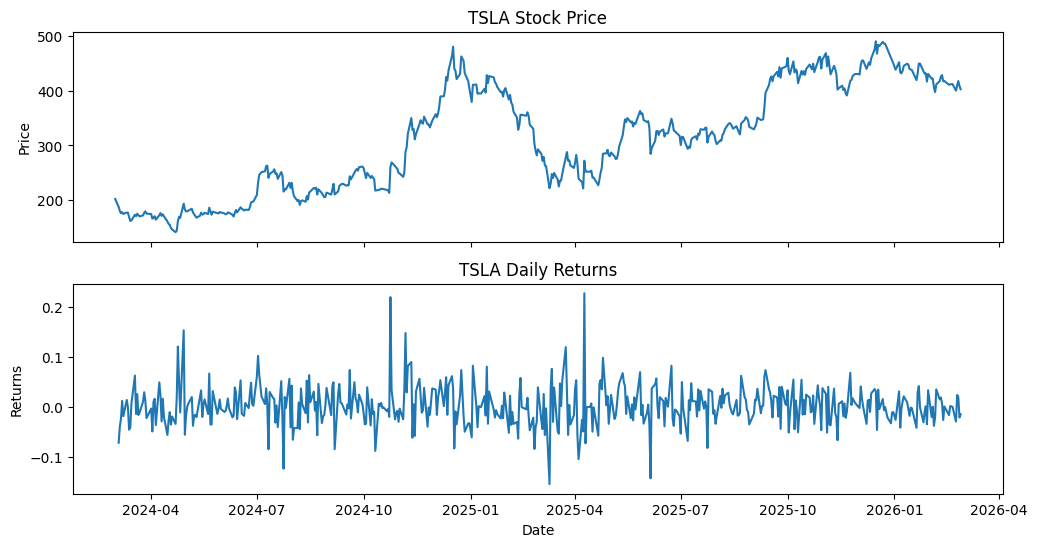

In [82]:
ticker = 'TSLA'
data = yf.download(ticker, start='2024-03-01', end='2026-03-01')
prices = data['Close'][ticker]
returns = prices.pct_change().dropna()
fig, ax = plt.subplots(figsize=(12, 6), nrows=2, sharex=True)
ax[1].plot(returns.index, returns.values)
ax[0].plot(prices.index, prices.values)
ax[0].set_title(f'{ticker} Stock Price')
ax[1].set_title(f'{ticker} Daily Returns')
ax[1].set_xlabel('Date')
ax[0].set_ylabel('Price')
ax[1].set_ylabel('Returns')

plt.show()

In [83]:
# Split data into train and test sets
train, test = train_test_split(returns, test_size=0.2, shuffle=False)
prices_train, prices_test = train_test_split(prices, test_size=0.2, shuffle=False)

### 

### Exploratory

In [84]:
print(f'Train size: {len(train)}, Test size: {len(test)}')

# ADF Test
adf_result = adfuller(train)
print(f'\nADF Test:')
print(f'  ADF Statistic: {adf_result[0]}')
print(f'  p-value: {adf_result[1]}')
print(f'  Decision: {"Stationary" if adf_result[1] < 0.05 else "Non-Stationary"}')
print(f'\nDifferencing needed: {"Yes" if adf_result[1] >= 0.05 else "No"}')


Train size: 399, Test size: 100

ADF Test:
  ADF Statistic: -19.97004161213686
  p-value: 0.0
  Decision: Stationary

Differencing needed: No


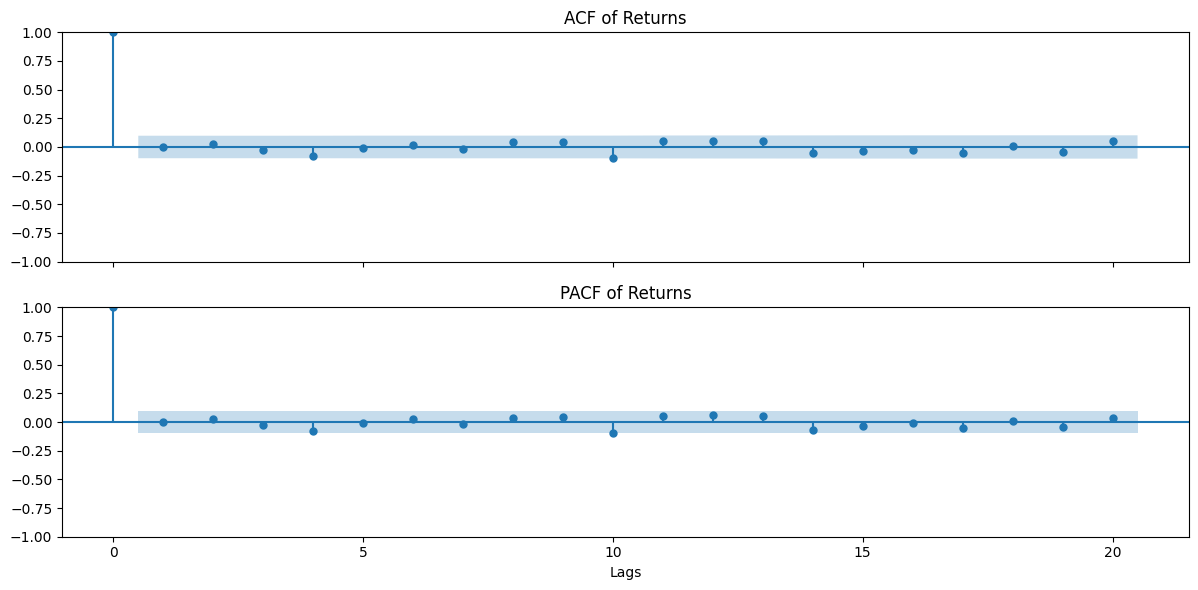

In [85]:
fig, ax = plt.subplots(figsize=(12, 6), nrows=2, sharex=True)
plot_acf(train, ax=ax[0], lags=20)
plot_pacf(train, ax=ax[1], lags=20)
ax[1].set_xlabel('Lags')
ax[0].set_title('ACF of Returns')
ax[1].set_title('PACF of Returns')
plt.tight_layout()
plt.show()

### Model fitting

In [86]:
best_aic = np.inf
best_bic = np.inf
best_order_aic = None
best_order_bic = None

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(train, order=(p, 0, q))
            results = model.fit()
            print(f'ARIMA({p},0,{q}) - AIC: {results.aic:.2f}, BIC: {results.bic:.2f}')
            if results.aic < best_aic:
                best_aic = results.aic
                best_order_aic = (p, 0, q)
            if results.bic < best_bic:
                best_bic = results.bic
                best_order_bic = (p, 0, q)
        except Exception as e:
            print(f'Error fitting ARIMA({p},0,{q}): {e}')
print(f'\nBest AIC: {best_aic} with order {best_order_aic}')
print(f'Best BIC: {best_bic} with order {best_order_bic}')

ARIMA(0,0,0) - AIC: -1388.38, BIC: -1380.41
ARIMA(0,0,1) - AIC: -1386.38, BIC: -1374.42
ARIMA(0,0,2) - AIC: -1384.65, BIC: -1368.69
ARIMA(0,0,3) - AIC: -1382.87, BIC: -1362.93
ARIMA(1,0,0) - AIC: -1386.38, BIC: -1374.42
ARIMA(1,0,1) - AIC: -1384.38, BIC: -1368.43
ARIMA(1,0,2) - AIC: -1382.41, BIC: -1362.46
ARIMA(1,0,3) - AIC: -1381.86, BIC: -1357.93
ARIMA(2,0,0) - AIC: -1384.60, BIC: -1368.65
ARIMA(2,0,1) - AIC: -1382.60, BIC: -1362.66
ARIMA(2,0,2) - AIC: -1384.53, BIC: -1360.60
ARIMA(2,0,3) - AIC: -1380.72, BIC: -1352.80
ARIMA(3,0,0) - AIC: -1382.85, BIC: -1362.91
ARIMA(3,0,1) - AIC: -1381.89, BIC: -1357.96
ARIMA(3,0,2) - AIC: -1381.42, BIC: -1353.49
ARIMA(3,0,3) - AIC: -1380.30, BIC: -1348.39

Best AIC: -1388.3840692552144 with order (0, 0, 0)
Best BIC: -1380.4061464214346 with order (0, 0, 0)


In [87]:
# Based on AIC and BIC, we choose random walk
model = ARIMA(train, order=(0, 0, 0))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                  399
Model:                          ARIMA   Log Likelihood                 696.192
Date:                Mon, 30 Mar 2026   AIC                          -1388.384
Time:                        12:35:39   BIC                          -1380.406
Sample:                             0   HQIC                         -1385.224
                                - 399                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0028      0.002      1.252      0.211      -0.002       0.007
sigma2         0.0018    7.5e-05     23.822      0.000       0.002       0.002
Ljung-Box (L1) (Q):                   0.00   Jarque-

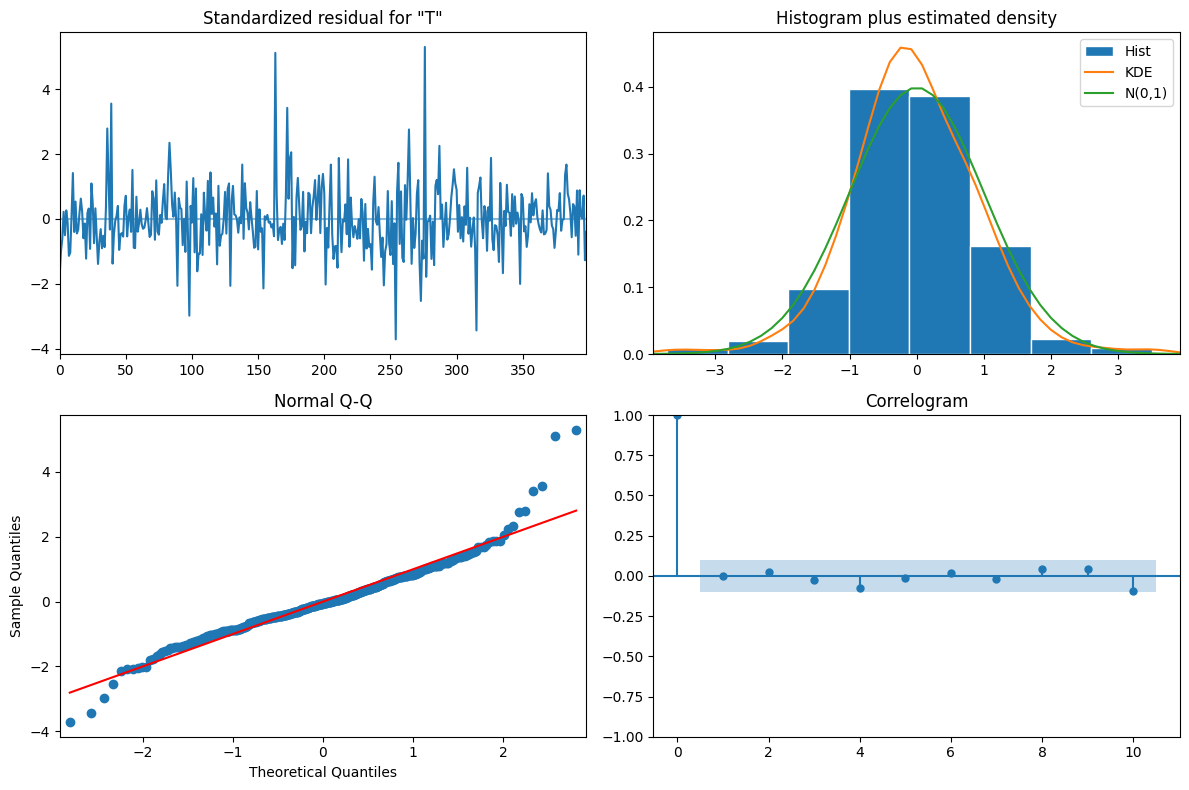

In [88]:
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

### Model evaluation
#### Test set forecast

In [89]:
pred_train = results.fittedvalues
pred_test = results.forecast(steps=len(test))
mse_train = mean_squared_error(train, pred_train)
mae_train = mean_absolute_error(train, pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train, pred_train)

mse_test = mean_squared_error(test, pred_test)
mae_test = mean_absolute_error(test, pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(test, pred_test)

metrics_df = pd.DataFrame({
    'MSE': [mse_train, mse_test],
    'MAE': [mae_train, mae_test],
    'RMSE': [rmse_train, rmse_test],
    'R2': [r2_train, r2_test]
}, index=["train", "test"])
metrics_df

,MSE,MAE,RMSE,R2
train,0.001786,0.030786,0.042266,-1.384553e-08
test,0.000723,0.021685,0.026882,-1.311901e-02


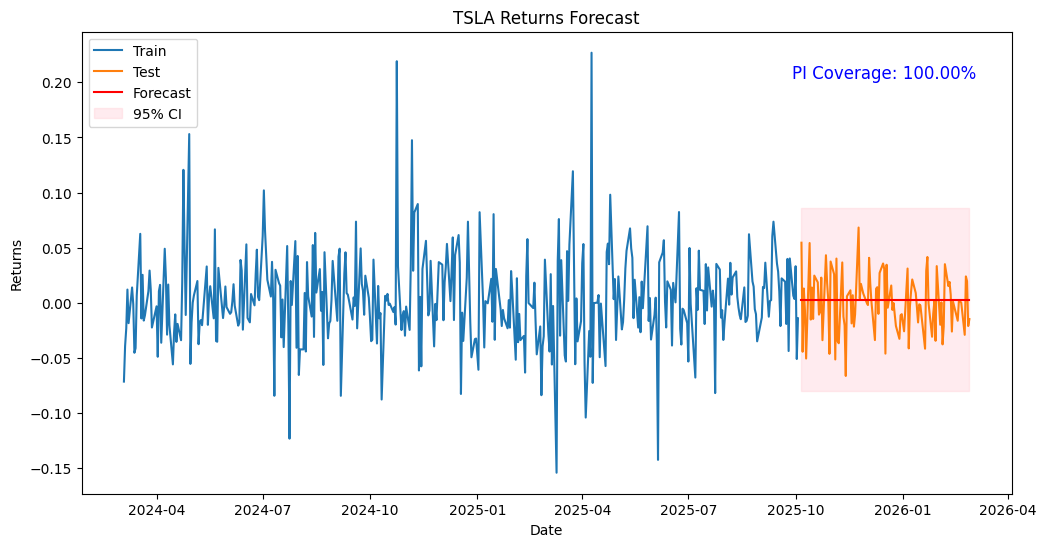

In [ ]:
forecast_steps = len(test)
forecast_result = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_mean.index = test.index[:forecast_steps]
forecast_ci = forecast_result.conf_int()
forecast_ci.index = forecast_mean.index
coverage = ((forecast_ci.iloc[:, 0] <= test[:forecast_steps]) & (test[:forecast_steps] <= forecast_ci.iloc[:, 1])).mean()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.plot(test.index[:forecast_steps], forecast_mean.values, label='Forecast', color='red')
plt.fill_between(test.index[:forecast_steps], forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3, label='95% CI')
plt.text(test.index[forecast_steps//2], 0.2, f'PI Coverage: {coverage:.2%}', ha='center', va='bottom', fontsize=12, color='blue')
plt.title(f'{ticker} Returns Forecast')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

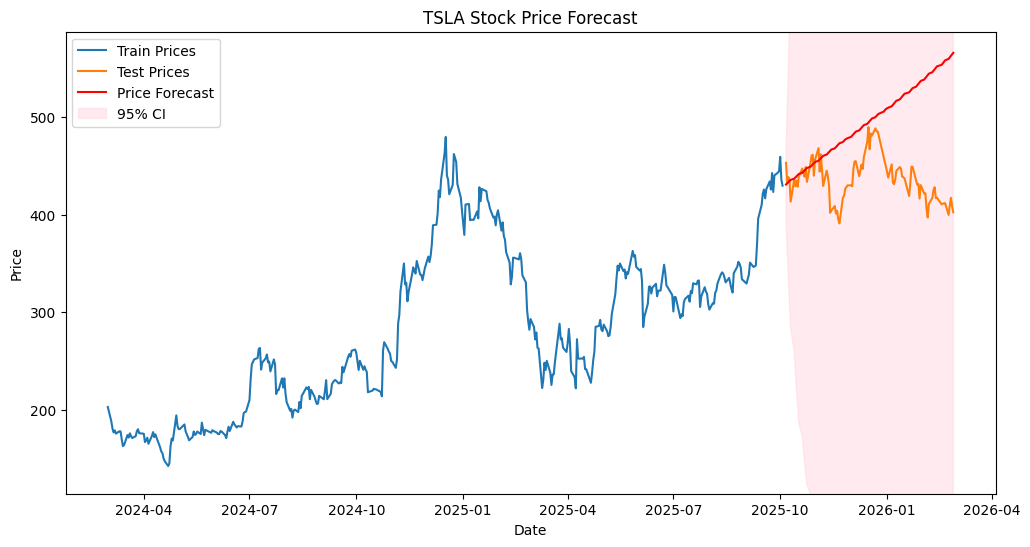

In [134]:
# Stock price forecast
last_price = prices_train.iloc[-1]
price_forecast = last_price * (1 + forecast_mean).cumprod()
price_PIs = last_price * (1 + forecast_ci).cumprod()


plt.figure(figsize=(12, 6))
plt.plot(prices_train.index, prices_train.values, label='Train Prices')
plt.plot(prices_test.index, prices_test.values, label='Test Prices')
plt.plot(test.index[:forecast_steps], price_forecast.values, label='Price Forecast', color='red')
plt.fill_between(test.index[:forecast_steps], price_PIs.iloc[:, 0], price_PIs.iloc[:, 1], color='pink', alpha=0.3, label='95% CI')
plt.ylim(prices.min() * 0.8, prices.max() * 1.2)
plt.title(f'{ticker} Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

#### test set one step ahead forecast

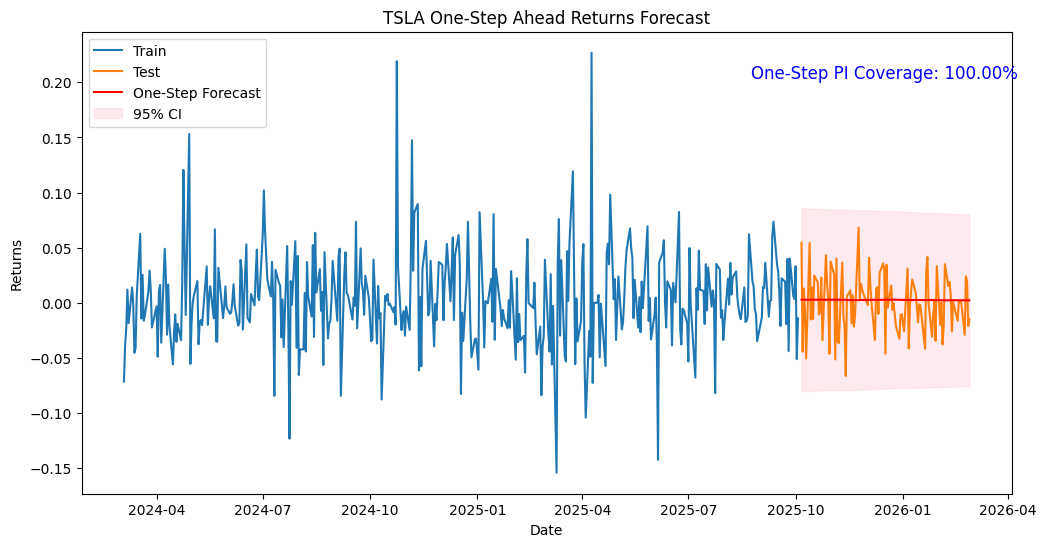

In [127]:
# one step ahead forecast + refit loop
history = list(train)
predictions = []
PIs = []
for t in range(len(test)):
    model = ARIMA(history, order=(0, 0, 0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    pi = model_fit.get_forecast(steps=1).conf_int()
    PIs.append(pi)
    predictions.append(yhat)
    history.append(test.iloc[t])
predictions = pd.Series(predictions, index=test.index)
PIs_df = pd.DataFrame(np.array(PIs).reshape(-1, 2), index=test.index, columns=['lower', 'upper'])
coverage_one_step = ((PIs_df['lower'] <= test) & (test <= PIs_df['upper'])).mean() 
plt.figure(figsize=(12, 6))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.plot(predictions.index, predictions.values, label='One-Step Forecast', color='red')
plt.fill_between(PIs_df.index, PIs_df['lower'], PIs_df['upper'], color='pink', alpha=0.3, label='95% CI')
plt.text(test.index[len(test)//2], 0.2, f'One-Step PI Coverage: {coverage_one_step:.2%}', ha='center', va='bottom', fontsize=12, color='blue')
plt.title(f'{ticker} One-Step Ahead Returns Forecast')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

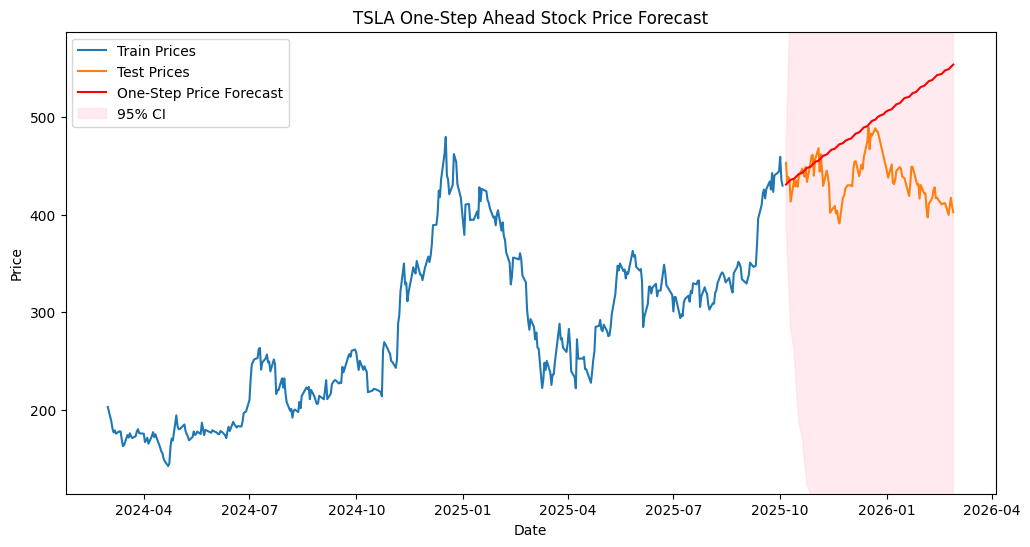

In [130]:
# now for stock price
last_price = prices_train.iloc[-1]
price_predictions = last_price * (1 + predictions).cumprod()
price_PIs_lower = last_price * (1 + PIs_df['lower']).cumprod()
price_PIs_upper = last_price * (1 + PIs_df['upper']).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(prices_train.index, prices_train.values, label='Train Prices')
plt.plot(prices_test.index, prices_test.values, label='Test Prices')
plt.plot(predictions.index, price_predictions.values, label='One-Step Price Forecast', color='red')
plt.fill_between(price_PIs_lower.index, price_PIs_lower.values, price_PIs_upper.values, color='pink', alpha=0.3, label='95% CI')
plt.ylim(prices.min() * 0.8, prices.max() * 1.2)
plt.title(f'{ticker} One-Step Ahead Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

## Problem 3.4: GARCH for Volatility (25 points)
Model volatility clustering in financial returns:

• Calculate daily returns for S&P 500 index.

• Fit GARCH(1,1) model to returns.

• Forecast volatility for next 20 days.

• Validate using realized volatility.